In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import numpy as np

In [15]:
# Generate Data and Splitting
X,y = make_classification(n_samples=1000, n_features=20, n_classes=3, n_informative=10, random_state=42)
y_bin= label_binarize(y, classes=np.unique(y))
X_train, X_test, y_train,y_test=train_test_split(X,y_bin, test_size=0.20, random_state=42)

In [19]:
logistic_model = OneVsRestClassifier(LogisticRegression(random_state=42))
logistic_model.fit(X_train, y_train)

rf_model = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, random_state=42))
rf_model.fit(X_train, y_train)

OneVsRestClassifier(estimator=RandomForestClassifier(random_state=42))

In [21]:
import matplotlib.pyplot as plt

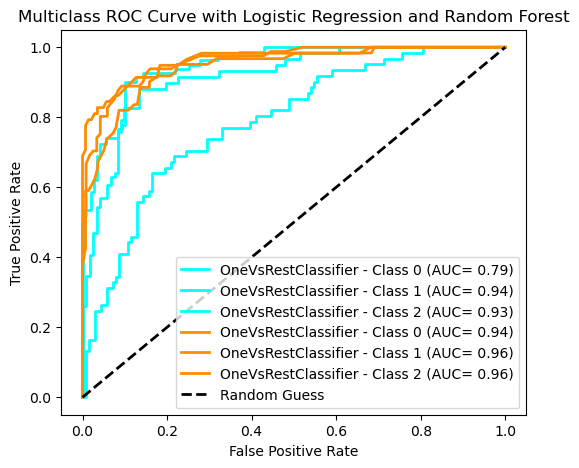

In [22]:
# Plot the AUC-ROC  Curve
fpr=dict()
tpr=dict()
roc_auc=dict()

models =[logistic_model, rf_model]

plt.figure(figsize=(6,5))
colors= cycle(['aqua', 'darkorange'])

for model, color in zip(models, colors):
    for i in range(model.classes_.shape[0]):
        fpr[i], tpr[i],_=roc_curve(y_test[:,i], model.predict_proba(X_test)[:,i])
        roc_auc[i]=auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{model.__class__.__name__} - Class {i} (AUC= {roc_auc[i]:.2f})')
        
plt.plot([0,1], [0,1], 'k--', lw=2, label='Random Guess')        
plt.xlabel('False Positive Rate')
plt.ylabel("True Positive Rate")
plt.title('Multiclass ROC Curve with Logistic Regression and Random Forest')
plt.legend(loc='lower right')
plt.show()
